In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [42]:
df=pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
X=df.iloc[:,1:]
Y=df.iloc[:,0]

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=True)

In [46]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [47]:
from sklearn.neighbors import KNeighborsClassifier

In [48]:
knn=KNeighborsClassifier()

In [49]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [50]:
y_pred=knn.predict(x_test)

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9671428571428572


In [52]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [53]:
from sklearn.decomposition import PCA
pca=PCA(n_components=None)

In [54]:
x_train_trf=pca.fit_transform(x_train_scaled)
x_test_trf=pca.transform(x_test_scaled)

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
knn1=KNeighborsClassifier()

In [57]:
knn1.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [58]:
y_pred=knn1.predict(x_test_trf)

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9416666666666667


In [60]:
#PCA 
from sklearn.decomposition import PCA
pca1=PCA(n_components=200)

In [61]:
x_train_trf=pca1.fit_transform(x_train_scaled)
x_test_trf=pca1.transform(x_test_scaled)
x_train_trf

array([[ -6.55495856,  -3.90137798,   3.70364164, ...,  -0.32978407,
          0.7386262 ,   0.36709312],
       [  1.49107796,  -0.56342489,   0.98328078, ...,  -0.09251579,
          0.31318365,  -1.3761614 ],
       [  5.48649477, -11.19774764,   2.85845988, ...,  -0.90320042,
         -0.53386347,  -0.87860063],
       ...,
       [  2.55665779,   0.85368265,   2.66611936, ...,   1.48670248,
          0.487157  ,  -0.15260894],
       [ -6.9269496 ,  -1.95682684,   2.79571431, ...,  -0.10002801,
         -0.21264874,   0.26858332],
       [ -5.69200233,  -3.80156568,   1.86687154, ...,   0.20900826,
          0.0174151 ,  -0.18007749]])

In [62]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()

In [63]:
KNN.fit(x_train_trf, y_train)

KNeighborsClassifier()

In [64]:
y_pred = KNN.predict(x_test_trf)

In [65]:
y_pred

array([1, 5, 2, ..., 8, 8, 8])

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9513095238095238


In [71]:
# from sklearn.neighbors import KNeighborsClassifier
# for i in range(1,785):
#     pca=PCA(n_components=i)
#     x_train_trf=pca.fit_transform(x_train_scaled)
#     x_test_trf=pca.transform(x_test_scaled)

#     knn=KNeighborsClassifier()
#     knn.fit(x_train_trf,y_train)
#     y_pred=knn.predict(x_test_trf)
#     print(accuracy_score(y_test,y_pred))

In [73]:
# transforming to a 2D coordinate system
pca=PCA(n_components=2)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [74]:
x_train_trf

array([[-819.2564966 ,  636.13289676],
       [ 293.31470725,  356.75967077],
       [ 484.3551137 ,  427.00846574],
       ...,
       [ -19.01631177, -144.00652971],
       [-693.6242946 ,  289.19567498],
       [-705.52320947,  347.19763292]])

In [79]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=x_train_trf[:,0],
             y=x_train_trf[:,1],
               color=y_train_trf,
              color_discrete_sequence=px.colors.qualitative.G10
             )
fig.show()

In [85]:
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(df,x=x_train_trf[:,0],y=x_train_trf[:,1],z=x_train_trf[:,2],
                  color=y_train_trf
                 )
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()

In [93]:
pca1 = PCA(n_components=4)

x_train_trf = pca1.fit_transform(x_train_scaled)
x_test_trf = pca1.transform(x_test_scaled)

In [94]:
print(x_train_trf.shape)

(33600, 4)


In [95]:
import plotly.express as px

fig = px.scatter_3d(
    x=x_train_trf[:, 0],   # PC1
    y=x_train_trf[:, 1],   # PC2
    z=x_train_trf[:, 2],   # PC3
    color=x_train_trf[:, 3],  # PC4
    labels={
        "x": "PC1",
        "y": "PC2",
        "z": "PC3",
        "color": "PC4"
    }
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    title="4D PCA Visualization"
)

fig.show()

In [96]:
#transforming in 3D
pca=PCA(n_components=3)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [97]:
x_train_trf

array([[-819.2564966 ,  636.13289676, -178.6922682 ],
       [ 293.31470725,  356.75967077,  390.42404005],
       [ 484.3551137 ,  427.00846574, -816.73715653],
       ...,
       [ -19.01631177, -144.00652971, -327.87102279],
       [-693.6242946 ,  289.19567498,  -47.50232774],
       [-705.52320947,  347.19763292, -334.01678589]])

# *Finding the optimum number of Principle components*

In [101]:
pca.explained_variance_

array([334948.91709953, 244150.61473294, 210714.43564341])

In [102]:
pca.components_.shape

(3, 784)

In [103]:
pca.explained_variance_ratio_

array([0.09757185, 0.07112197, 0.06138189])

In [104]:
#transforming in 3D
pca=PCA(n_components=None)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [105]:
pca.explained_variance_

array([3.34948917e+05, 2.44150615e+05, 2.10714436e+05, 1.85258044e+05,
       1.67231446e+05, 1.48362935e+05, 1.12826765e+05, 9.92122727e+04,
       9.47583318e+04, 8.07820770e+04, 7.20932617e+04, 7.09666617e+04,
       5.86669862e+04, 5.83056140e+04, 5.39179465e+04, 5.09768936e+04,
       4.51807339e+04, 4.41050807e+04, 4.07294624e+04, 3.95528105e+04,
       3.67741456e+04, 3.48140735e+04, 3.31722330e+04, 3.12793360e+04,
       3.04917033e+04, 2.89705879e+04, 2.79239047e+04, 2.67676996e+04,
       2.53520216e+04, 2.35226276e+04, 2.26774800e+04, 2.18219818e+04,
       2.06971193e+04, 2.01408257e+04, 1.92751934e+04, 1.86822659e+04,
       1.74344266e+04, 1.67833664e+04, 1.62184997e+04, 1.60326945e+04,
       1.56465182e+04, 1.52841170e+04, 1.43456989e+04, 1.36599876e+04,
       1.31932390e+04, 1.28921520e+04, 1.24700903e+04, 1.19743345e+04,
       1.15950111e+04, 1.10257021e+04, 1.08971166e+04, 1.06720840e+04,
       1.00531230e+04, 9.78974845e+03, 9.63497452e+03, 9.23299004e+03,
      

In [106]:
pca.explained_variance_.shape

(784,)

In [107]:
pca.explained_variance_ratio_

array([9.75718452e-02, 7.11219675e-02, 6.13818861e-02, 5.39663461e-02,
       4.87151321e-02, 4.32186660e-02, 3.28668494e-02, 2.89008981e-02,
       2.76034488e-02, 2.35321146e-02, 2.10010309e-02, 2.06728482e-02,
       1.70899078e-02, 1.69846387e-02, 1.57064951e-02, 1.48497556e-02,
       1.31613131e-02, 1.28479714e-02, 1.18646414e-02, 1.15218784e-02,
       1.07124432e-02, 1.01414670e-02, 9.66319285e-03, 9.11178504e-03,
       8.88234475e-03, 8.43923826e-03, 8.13433563e-03, 7.79752885e-03,
       7.38513665e-03, 6.85222748e-03, 6.60603290e-03, 6.35682316e-03,
       6.02914659e-03, 5.86709622e-03, 5.61493436e-03, 5.44221241e-03,
       5.07871227e-03, 4.88905605e-03, 4.72450831e-03, 4.67038257e-03,
       4.55788800e-03, 4.45231921e-03, 4.17895458e-03, 3.97920438e-03,
       3.84323881e-03, 3.75553106e-03, 3.63258295e-03, 3.48816745e-03,
       3.37766915e-03, 3.21182736e-03, 3.17436994e-03, 3.10881713e-03,
       2.92851152e-03, 2.85178954e-03, 2.80670333e-03, 2.68960378e-03,
      

In [108]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09757185, 0.16869381, 0.2300757 , 0.28404204, 0.33275718,
       0.37597584, 0.40884269, 0.43774359, 0.46534704, 0.48887915,
       0.50988018, 0.53055303, 0.54764294, 0.56462758, 0.58033407,
       0.59518383, 0.60834514, 0.62119311, 0.63305776, 0.64457963,
       0.65529208, 0.66543354, 0.67509674, 0.68420852, 0.69309087,
       0.70153011, 0.70966444, 0.71746197, 0.72484711, 0.73169933,
       0.73830537, 0.74466219, 0.75069134, 0.75655843, 0.76217337,
       0.76761558, 0.77269429, 0.77758335, 0.78230786, 0.78697824,
       0.79153613, 0.79598845, 0.8001674 , 0.80414661, 0.80798984,
       0.81174538, 0.81537796, 0.81886613, 0.82224379, 0.82545562,
       0.82862999, 0.83173881, 0.83466732, 0.83751911, 0.84032581,
       0.84301542, 0.84565822, 0.84822825, 0.85076625, 0.85320905,
       0.85561874, 0.85801863, 0.86029715, 0.86251025, 0.86464991,
       0.8667312 , 0.86875906, 0.87071542, 0.87265597, 0.87454291,
       0.87641548, 0.87823225, 0.88000472, 0.88173333, 0.88340

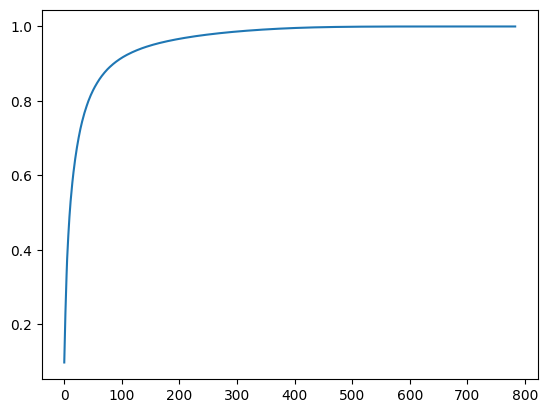

In [110]:
import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))

# When PCA does not work?